In [1]:
import sys
sys.path.append('../src')

from preprocess import load_and_preprocess

X_train, X_test, y_train, y_test, feature_names = load_and_preprocess('../data/telco_churn.csv')

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Churn rate in train:", y_train.mean().round(3))
print("Features:", feature_names)

X_train shape: (5634, 21)
X_test shape: (1409, 21)
Churn rate in train: 0.265
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group', 'charges_per_month_ratio']


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [4]:
def evaluate_model(name, y_test, y_pred, y_prob):
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)


--- Logistic Regression ---
Accuracy:  0.804
Precision: 0.662
Recall:    0.535
F1 Score:  0.592
ROC-AUC:   0.846


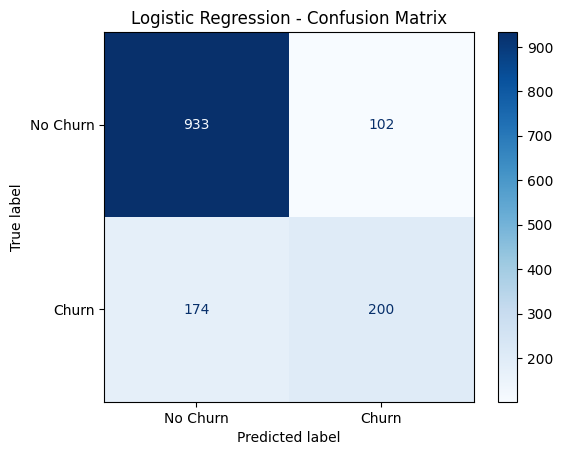

In [5]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)


--- Random Forest ---
Accuracy:  0.786
Precision: 0.625
Recall:    0.481
F1 Score:  0.544
ROC-AUC:   0.820


In [7]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)


--- XGBoost ---
Accuracy:  0.754
Precision: 0.524
Recall:    0.802
F1 Score:  0.634
ROC-AUC:   0.844


In [10]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_xgb)],
    'Recall':    [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_xgb)],
    'F1':        [f1_score(y_test, y_pred_lr),
                  f1_score(y_test, y_pred_rf),
                  f1_score(y_test, y_pred_xgb)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_lr),
                  roc_auc_score(y_test, y_prob_rf),
                  roc_auc_score(y_test, y_prob_xgb)]
}

results_df = pd.DataFrame(results).set_index('Model').round(3)
print(results_df)

                     Accuracy  Recall     F1  ROC-AUC
Model                                                
Logistic Regression     0.804   0.535  0.592    0.846
Random Forest           0.786   0.481  0.544    0.820
XGBoost                 0.754   0.802  0.634    0.844


In [11]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(xgb, '../models/xgb_churn.pkl')
print("Model saved to models/xgb_churn.pkl")

Model saved to models/xgb_churn.pkl
